In [1]:
import pandas as pd
import numpy as np
import scipy
import matplotlib.pyplot as plt

In [39]:
#Read Data
cv_df = pd.read_csv("cvdata.csv")
ts_df = pd.read_csv("tsDataThai.csv")

cv_df = cv_df.drop(columns=["Unnamed: 0"])
ts_df = ts_df.drop(columns=["Unnamed: 0"])

ts_df["Year"] = pd.to_numeric(ts_df["Year"], errors="coerce")
ts_df["Month"] = pd.to_numeric(ts_df["Month"], errors="coerce")

ts_df = ts_df.dropna(subset=["Year","Month"])

ts_df["Year"] = ts_df["Year"].astype(int)
ts_df["Month"] = ts_df["Month"].astype(int)


merged = ts_df.merge(
    cv_df,
    left_on=["Location", "Year", "Month"],
    right_on=["province", "Year", "Month"],
    how="left"
)

merged = merged.drop(columns=["province"])

merged["Date"] = pd.to_datetime(
    dict(year=merged.Year, month=merged.Month, day=1)
)

In [102]:
import pandas as pd
import numpy as np
from scipy.interpolate import UnivariateSpline

DISEASE = "Hand, Foot, and Mouth Disease (HFMD)"
YEAR_MIN, YEAR_MAX = 2003, 2019

agg_cols = [
    "Cases", "Tavg", "Tmin", "Tmax", "RH", "specific.hum", "srf.pressure",
    "shortwave.rad", "precip", "runoff", "cld.frac", "pct_tree", "pct_hveg",
    "pct_bare", "lai_climo"
]

# Use every province that has data for this disease + year range
filtered = merged[
    (merged["Disease"] == DISEASE) &
    (merged["Year"].between(YEAR_MIN, YEAR_MAX))
].copy()

all_provinces = sorted(filtered["Location"].dropna().unique())
weekly_frames = []

for province in all_provinces:
    df = filtered[filtered["Location"] == province].copy()

    if df.empty:
        print(f"[skip] {province}: no rows after filter")
        continue

    df["Date"] = pd.to_datetime(dict(year=df["Year"], month=df["Month"], day=1))

    monthly = (
        df.sort_values("Date")
          .groupby("Date", as_index=True)
          .agg({c: ("sum" if c == "Cases" else "first") for c in agg_cols})
    )

    # Need at least 4 monthly points for cubic spline (k=3)
    if len(monthly) < 4:
        print(f"[skip] {province}: too few monthly points for spline")
        continue

    weekly_index = pd.date_range(
        start=monthly.index.min(),
        end=monthly.index.max(),
        freq="W"
    )

    x_monthly = monthly.index.view("int64")
    x_weekly = weekly_index.view("int64")

    weekly_province = pd.DataFrame(index=weekly_index)

    for col in monthly.columns:
        y = monthly[col].values.astype(float)

        spline = UnivariateSpline(x_monthly, y, s=0)
        y_weekly = spline(x_weekly)

        if col == "Cases":
            y_weekly = np.clip(y_weekly, 0, None)
            y_weekly = np.round(y_weekly)

        weekly_province[col] = y_weekly

    weekly_province["Location"] = province
    weekly_province["Disease"] = DISEASE
    weekly_frames.append(weekly_province)

if not weekly_frames:
    raise ValueError("No province produced weekly data. Check filters and input data.")

weekly_df = pd.concat(weekly_frames).sort_index()

# Save to CSV
output_path = "thai_hfmd.csv"
weekly_out = weekly_df.reset_index().rename(columns={"index": "Date"})
weekly_out.to_csv(output_path, index=False)

print(f"Saved {len(weekly_out)} rows to {output_path}")
print(f"Built weekly_df for {weekly_df['Location'].nunique()} provinces")
print("Provinces:", sorted(weekly_df["Location"].unique()))
print(weekly_df.head(20))

Saved 68457 rows to thai_hfmd.csv
Built weekly_df for 78 provinces
Provinces: ['Amnat Charoen', 'Ang Thong', 'Bangkok', 'Bungkan', 'Buri Ram', 'Chachoengsao', 'Chai Nat', 'Chaiyaphum', 'Chanthaburi', 'Chiang Mai', 'Chiang Rai', 'Chon Buri', 'Chumphon', 'Kalasin', 'Kamphaeng Phet', 'Kanchanaburi', 'Khon Kaen', 'Krabi', 'Lampang', 'Lamphun', 'Loei', 'Lop Buri', 'Mae Hong Son', 'Maha Sarakham', 'Mukdahan', 'Nakhon Nayok', 'Nakhon Pathom', 'Nakhon Phanom', 'Nakhon Ratchasima', 'Nakhon Sawan', 'Nakhon Si Thammarat', 'Nan', 'Narathiwat', 'Nong Bua Lam Phu', 'Nong Khai', 'Nonthaburi', 'P.Nakhon S.Ayutthaya', 'Pathum Thani', 'Pattani', 'Phangnga', 'Phatthalung', 'Phayao', 'Phetchabun', 'Phetchaburi', 'Phichit', 'Phitsanulok', 'Phrae', 'Phuket', 'Prachin Buri', 'Prachuap Khiri Khan', 'Ranong', 'Ratchaburi', 'Rayong', 'Roi Et', 'Sa Kaeo', 'Sakon Nakhon', 'Samut Prakan', 'Samut Sakhon', 'Samut Songkhram', 'Saraburi', 'Satun', 'Si Sa Ket', 'Sing Buri', 'Songkhla', 'Sukhothai', 'Suphan Buri', 'Sura

In [ ]:
import pandas as pd
import numpy as np
from scipy.ndimage import gaussian_filter1d

# Configuration
province = "Chiang Mai"
disease = "Scrub Typhus"

# 1. Filter and Prepare Data
df = merged[
    (merged["Disease"] == disease) &
    (merged["Location"] == province) &
    (merged["Year"].between(2003, 2019))
].copy()

# Create date variable (assuming data is monthly points)
df["Date"] = pd.to_datetime(dict(year=df.Year, month=df.Month, day=1))

# 2. Aggregate to Monthly
monthly = (
    df.sort_values("Date")
      .groupby("Date")
      .agg({
          "Cases": "sum",
          "Tavg": "first", "Tmin": "first", "Tmax": "first",
          "RH": "first", "specific.hum": "first", "srf.pressure": "first",
          "shortwave.rad": "first", "precip": "first", "runoff": "first",
          "cld.frac": "first", "pct_tree": "first", "pct_hveg": "first",
          "pct_bare": "first", "lai_climo": "first"
      })
)

# 3. Reindex to Weekly Frequency
weekly_index = pd.date_range(
    start=monthly.index.min(),
    end=monthly.index.max(),
    freq="W"
)
weekly_df = monthly.reindex(weekly_index)

# 4. Monotonicity-Preserving Smooth Interpolation
# PCHIP is C1 continuous and guaranteed not to overshoot monthly peaks
weekly_df = weekly_df.interpolate(method='pchip')

# Handle edges (extrapolation for weeks before/after the first/last month)
weekly_df = weekly_df.ffill().bfill()

# 5. Apply Gaussian Smoothing for Physical Realism
# We apply a light sigma to environmental variables to eliminate sharp 'knots'
# while keeping the data grounded in the actual monthly observations.
cols_to_smooth = [c for c in weekly_df.columns if c not in ["Cases"]]
for col in cols_to_smooth:
    weekly_df[col] = gaussian_filter1d(weekly_df[col].astype(float), sigma=1.0)

# 6. Post-processing for Count Data
if "Cases" in weekly_df.columns:
    # Rounding and using nullable Int64 to prevent casting errors
    weekly_df["Cases"] = weekly_df["Cases"].clip(lower=0).round().astype("Int64")

# 7. Re-add Identifiers
weekly_df["Location"] = province
weekly_df["Disease"] = disease
weekly_df.index.name = "Date"

print(f"Upsampling complete. New shape: {weekly_df.shape}")
print(weekly_df.head(20))

Upsampling complete. New shape: (883, 17)
            Cases        Tavg        Tmin        Tmax         RH  \
Date                                                               
2003-01-05     28  296.230000  293.140000  303.160000  86.680000   
2003-01-12     28  296.230000  293.140000  303.160000  86.680000   
2003-01-19     28  296.230000  293.140000  303.160000  86.680000   
2003-01-26     28  296.230000  293.140000  303.160000  86.680000   
2003-02-02     28  296.230000  293.140000  303.160000  86.680000   
2003-02-09     28  296.230000  293.140000  303.160000  86.680000   
2003-02-16     28  296.230000  293.140000  303.160000  86.680000   
2003-02-23     28  296.230000  293.140000  303.160000  86.680000   
2003-03-02     28  296.230000  293.140000  303.160000  86.680000   
2003-03-09     28  296.230000  293.140000  303.160000  86.680000   
2003-03-16     28  296.230000  293.140000  303.160000  86.680000   
2003-03-23     28  296.230000  293.140000  303.160000  86.680000   
2003-0

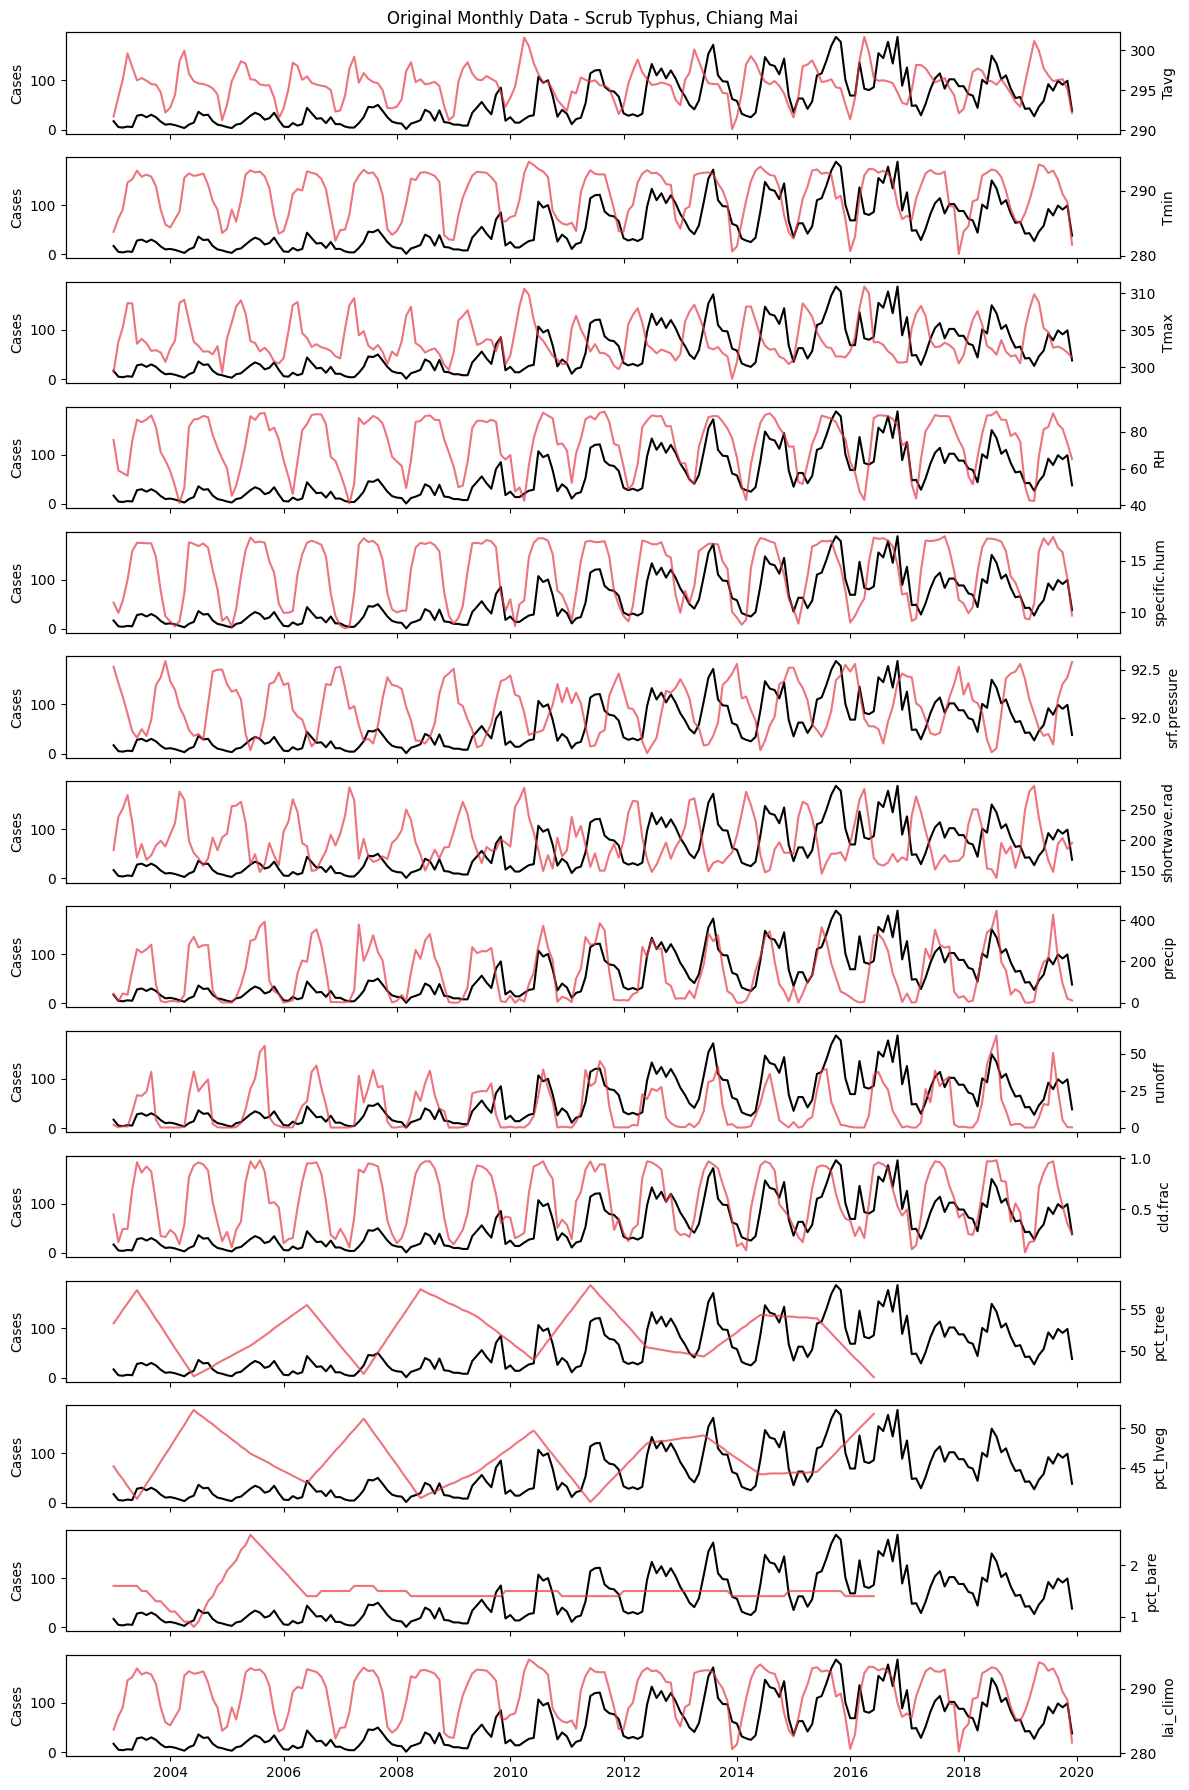

In [48]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Re-create the monthly data from the original 'merged' dataframe 
# (This ensures we see the raw data points, not the interpolated ones)
province = "Chiang Mai"
disease = "Scrub Typhus"

df_monthly_raw = merged[
    (merged["Disease"] == disease) &
    (merged["Location"] == province) &
    (merged["Year"].between(2003, 2019))
].copy()

df_monthly_raw["Date"] = pd.to_datetime(dict(year=df_monthly_raw.Year, month=df_monthly_raw.Month, day=1))

# Aggregate exactly like before
monthly_plot_df = (
    df_monthly_raw.sort_values("Date")
    .groupby("Date")
    .agg({
        "Cases": "sum",
        "Tavg": "first", "Tmin": "first", "Tmax": "first",
        "RH": "first", "specific.hum": "first", "srf.pressure": "first",
        "shortwave.rad": "first", "precip": "first", "runoff": "first",
        "cld.frac": "first", "pct_tree": "first", "pct_hveg": "first",
        "pct_bare": "first", "lai_climo": "first"
    })
)

# 2. Plotting
covariates = [
    "Tavg", "Tmin", "Tmax", "RH", "specific.hum",
    "srf.pressure", "shortwave.rad", "precip",
    "runoff", "cld.frac", "pct_tree", "pct_hveg",
    "pct_bare", "lai_climo"
]

fig, axes = plt.subplots(len(covariates), 1, figsize=(12, 18), sharex=True)

for ax, cov in zip(axes, covariates):
    # Plot Monthly Cases as a step or bar to show the 'chunk' of time they represent
    ax.plot(monthly_plot_df.index, monthly_plot_df["Cases"], color="black", linewidth=1.5, label="Monthly Cases")
    
    ax2 = ax.twinx()
    # Plot Monthly Covariates
    ax2.plot(monthly_plot_df.index, monthly_plot_df[cov], color="#e63946",  alpha=0.7, label=cov)

    ax.set_ylabel("Cases")
    ax2.set_ylabel(cov)

axes[0].set_title(f"Original Monthly Data - {disease}, {province}")

plt.tight_layout()
plt.show()

# Covariate vs Cases

The code below is just to view how covariates lead cases, feel free to change the the location.

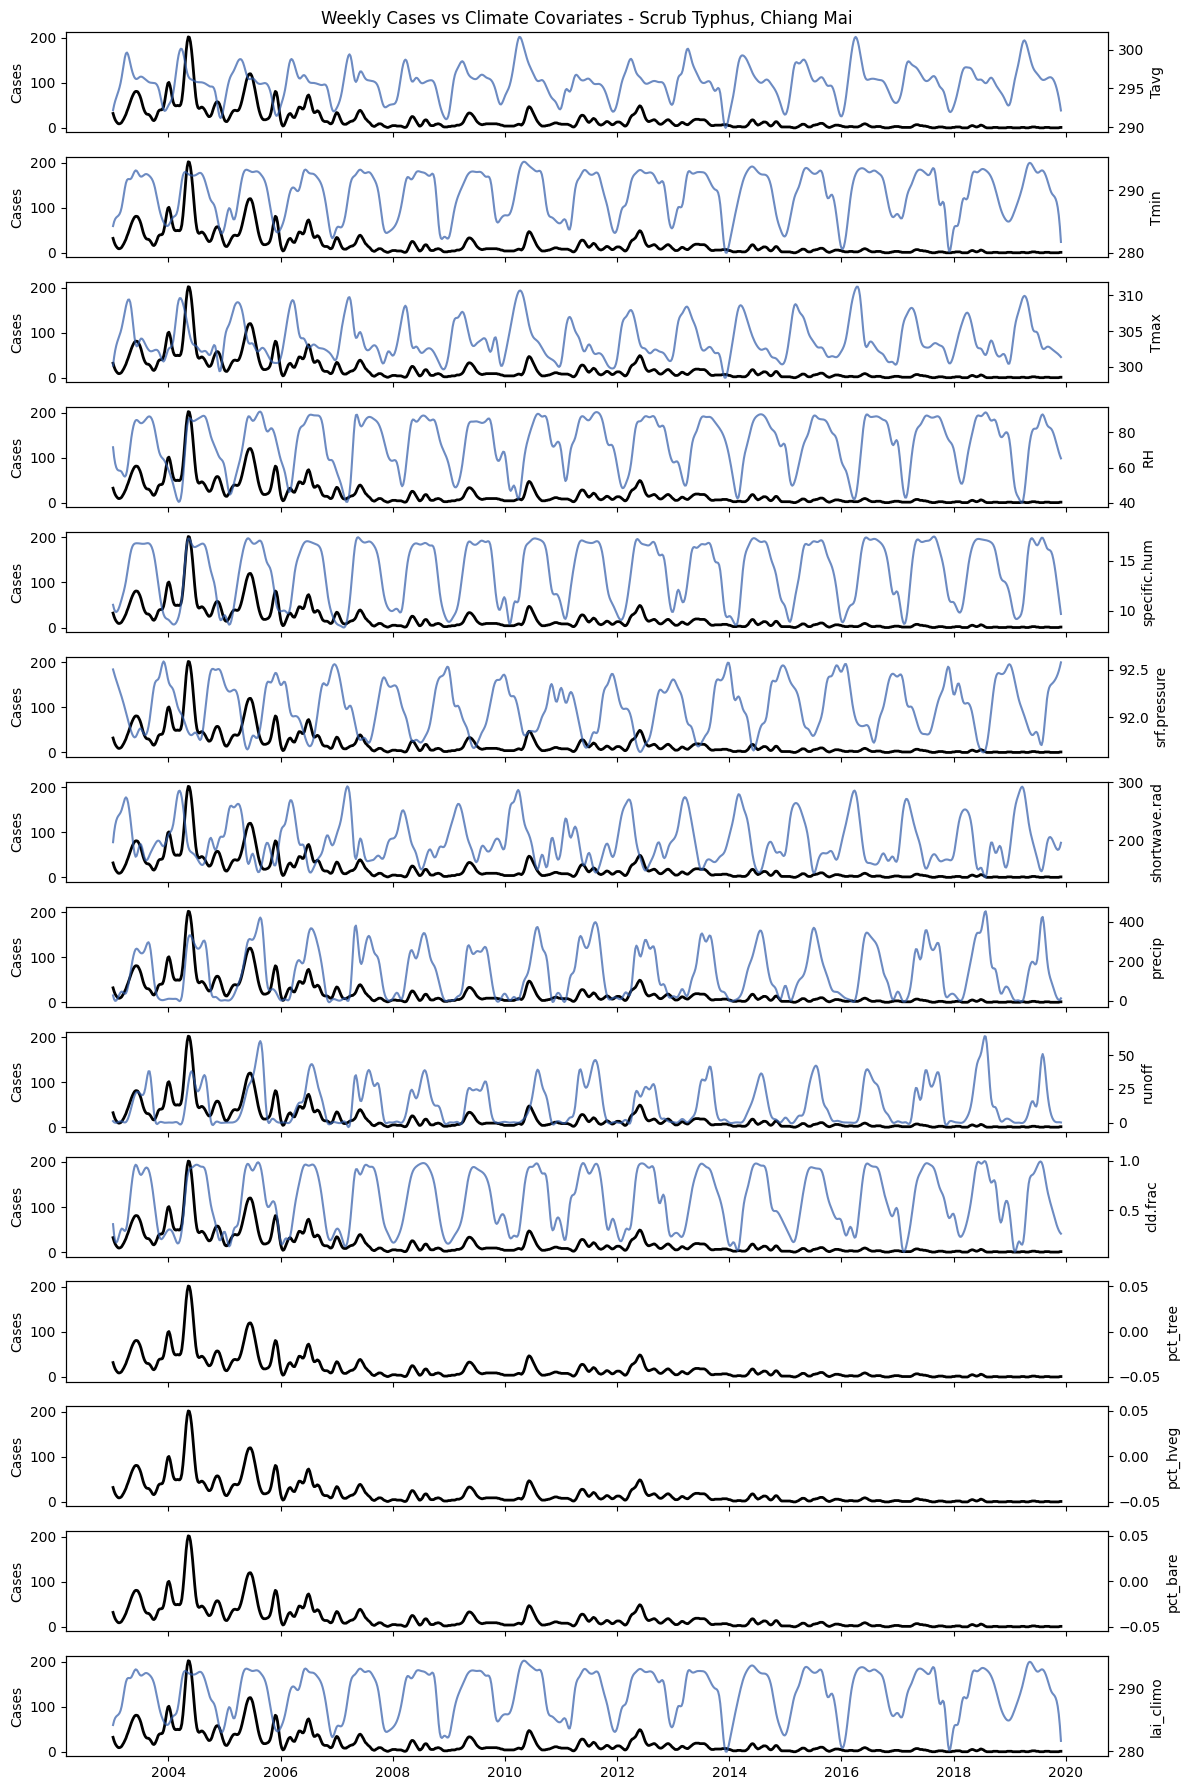

In [57]:
import matplotlib.pyplot as plt

province = "Chiang Mai"
df = weekly_df[weekly_df["Location"] == province].sort_index()

covariates = [
    "Tavg","Tmin","Tmax","RH","specific.hum",
    "srf.pressure","shortwave.rad","precip",
    "runoff","cld.frac","pct_tree","pct_hveg",
    "pct_bare","lai_climo"
]

fig, axes = plt.subplots(len(covariates), 1, figsize=(12,18), sharex=True)

for ax, cov in zip(axes, covariates):

    ax.plot(df.index, df["Cases"], color="black", linewidth=2, label="Cases")
    
    ax2 = ax.twinx()
    ax2.plot(df.index, df[cov], color="#2f5aa8", alpha=0.7, label=cov)

    ax.set_ylabel("Cases")
    ax2.set_ylabel(cov)

axes[0].set_title("Weekly Cases vs Climate Covariates - Scrub Typhus, Chiang Mai")

plt.tight_layout()
plt.show()

In [5]:
# Clone the full Mantis repository and move into it
!git clone https://github.com/carsondudley1/Mantis.git

fatal: destination path 'Mantis' already exists and is not an empty directory.


In [6]:
%pip install -e ./Mantis

Obtaining file:///Users/cdud/Desktop/Research/marisa_research/mantis/mantis_eval/Mantis
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for mantis (pyproject.toml) ... done
  Created wheel for mantis: filename=mantis-1.0.0-0.editable-py3-none-any.whl size=4702 sha256=2bbc7ae06e844149b32247c41bd238a3b49a742fdd8ae8c8a20835eee6310fbc
  Stored in directory: /private/var/folders/xg/zt0mzlm94hj6z72xf8h0n6t40000gn/T/pip-ephem-wheel-cache-qa_pxqku/wheels/77/c4/e7/50b964c1b70bab82040d0b4ba31a727eabadcfc3325458fb4e
Successfully built mantis
  Attempting uninstall: mantis
    Found existing installation: mantis 1.0.0
    Uninstalling mantis-1.0.0:
      Successfully uninstalled mantis-1.0.0
Note: you may need to restart the kernel to use updated packages.


In [49]:
# Download the 4-week model that takes covariates

!mkdir -p models
!curl -L -o models/mantis_8w_cov.pt https://github.com/carsondudley1/Mantis/releases/download/mantis-v1.0/mantis_8w_cov.pt

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1179M  100 1179M    0     0  44.5M      0  0:00:26  0:00:26 --:--:-- 42.5M:09 42.5M 0  44.7M      0  0:00:26  0:00:24  0:00:02 45.4M


In [8]:
!curl -L -o models/mantis_4w_nocov.pt https://github.com/carsondudley1/Mantis/releases/download/mantis-v1.0/mantis_4w_nocov.pt

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1179M  100 1179M    0     0  24.1M      0  0:00:48  0:00:48 --:--:-- 28.2M  0  0:01:03  0:00:17  0:00:46 32.5M00:33 35.6M  0  0:00:51  0:00:23  0:00:28 35.1M


In [50]:
from mantis import Mantis

# 4-week Covariate Mantis
 Cases = Hospitalizations 
 
 Covariate = Cases

/Users/cdud/Desktop/Research/marisa_research/mantis/mantis_eval/Mantis/mantis/inference.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_pa

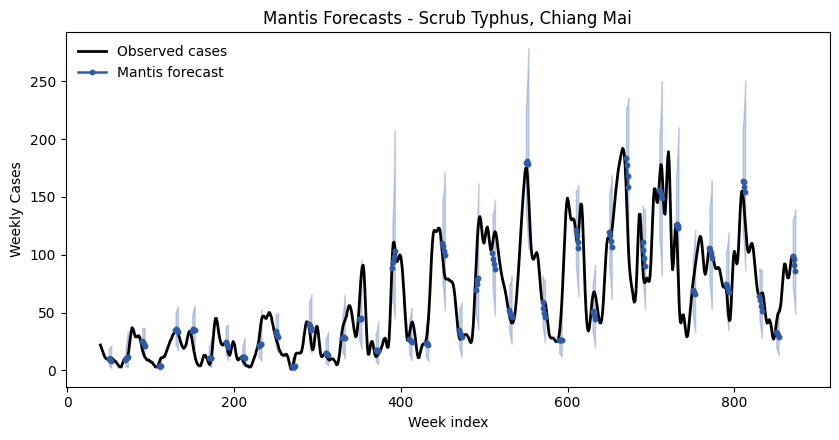

In [11]:
# Load dataset
df = weekly_df.copy()

# Select province
province = "Chiang Mai"
df = df[df["Location"] == province].sort_index()


# Target covariate
cases_ts = df["Cases"].values          # target
weather_ts = df["Tmax"].values         # covariate

# Initialize model
model = Mantis(
    forecast_horizon=4,
    use_covariate=True
)

# Forecast weeks
forecast_weeks = list(range(50, len(cases_ts)-4, 20))

forecasts = []
ground_truths = []
start_weeks = []

for week in forecast_weeks:

    if week + 4 > len(cases_ts):
        continue

    # Leading signal = cases
    input_target = cases_ts[:week]

    # Lagging signal = weather
    input_cov = weather_ts[:week]

    true_future = cases_ts[week:week + 4]

    pred = model.predict(
        time_series=input_target,
        covariate=input_cov,
        target_type=1,       # generic target
        covariate_type=0     # generic covariate
    )

    forecasts.append(pred)
    ground_truths.append(true_future)
    start_weeks.append(week)

# Plotting window
history_weeks = 10

first_week = int(start_weeks[0])
start_plot = max(0, first_week - history_weeks)
end_plot = int(start_weeks[-1]) + 4

weeks = np.arange(start_plot, end_plot)
truth_slice = cases_ts[start_plot:end_plot]

# Plot
fig, ax = plt.subplots(figsize=(8.5, 4.5))

# Ground truth
ax.plot(
    weeks,
    truth_slice,
    color="black",
    linewidth=2,
    label="Observed cases"
)

labeled = False

for start, forecast in zip(start_weeks, forecasts):

    pred_weeks = np.arange(start, start + 4)

    median = forecast[:, 4]
    lower = forecast[:, 0]
    upper = forecast[:, 8]

    ax.fill_between(
        pred_weeks,
        lower,
        upper,
        color="#2f5aa8",
        alpha=0.25
    )

    ax.plot(
        pred_weeks,
        median,
        color="#2f5aa8",
        linewidth=1.8,
        marker="o",
        markersize=3.2,
        label="Mantis forecast" if not labeled else None
    )

    labeled = True

# Labels
ax.set_title("Mantis Forecasts - Scrub Typhus, Chiang Mai")
ax.set_xlabel("Week index")
ax.set_ylabel("Weekly Cases")

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

# 4-week Covariate Mantis
 Cases = Deaths
 
 Meteorological Covariate = Hospitalizations

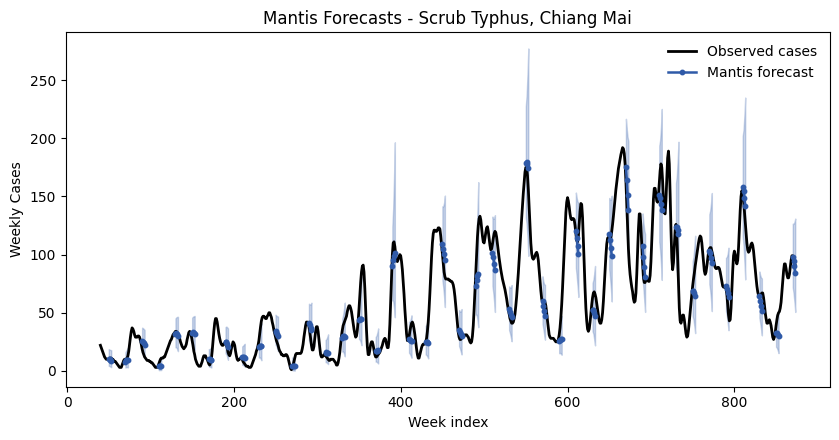

In [12]:
# Load dataset
df = weekly_df.copy()

# Select province
province = "Chiang Mai"
df = df[df["Location"] == province].sort_index()


# Target and covariate series
cases_ts = df["Cases"].values          # target
weather_ts = df["Tmax"].values         # covariate

# Initialize model
model = Mantis(
    forecast_horizon=4,
    use_covariate=True
)


# Forecast weeks
forecast_weeks = list(range(50, len(cases_ts)-4, 20))

forecasts = []
ground_truths = []
start_weeks = []

for week in forecast_weeks:

    if week + 4 > len(cases_ts):
        continue

    # Leading signal = cases
    input_target = cases_ts[:week]

    # Lagging signal = weather
    input_cov = weather_ts[:week]

    true_future = cases_ts[week:week + 4]

    pred = model.predict(
        time_series=input_target,
        covariate=input_cov,
        target_type=2,       # generic target
        covariate_type=1     # generic covariate
    )

    forecasts.append(pred)
    ground_truths.append(true_future)
    start_weeks.append(week)

# Plot window
history_weeks = 10

first_week = int(start_weeks[0])
start_plot = max(0, first_week - history_weeks)
end_plot = int(start_weeks[-1]) + 4

weeks = np.arange(start_plot, end_plot)
truth_slice = cases_ts[start_plot:end_plot]

# Plot
fig, ax = plt.subplots(figsize=(8.5, 4.5))

# Ground truth
ax.plot(
    weeks,
    truth_slice,
    color="black",
    linewidth=2,
    label="Observed cases"
)

labeled = False

for start, forecast in zip(start_weeks, forecasts):

    pred_weeks = np.arange(start, start + 4)

    median = forecast[:, 4]
    lower = forecast[:, 0]
    upper = forecast[:, 8]

    ax.fill_between(
        pred_weeks,
        lower,
        upper,
        color="#2f5aa8",
        alpha=0.25
    )

    ax.plot(
        pred_weeks,
        median,
        color="#2f5aa8",
        linewidth=1.8,
        marker="o",
        markersize=3.2,
        label="Mantis forecast" if not labeled else None
    )

    labeled = True

# Labels
ax.set_title("Mantis Forecasts - Scrub Typhus, Chiang Mai")
ax.set_xlabel("Week index")
ax.set_ylabel("Weekly Cases")

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

--- Performance Metrics: Chiang Mai ---
Model MAE:         4.024
Baseline MAE:      4.293
Relative MAE:      0.937 (Model / Baseline)
Interval Coverage: 95.7%


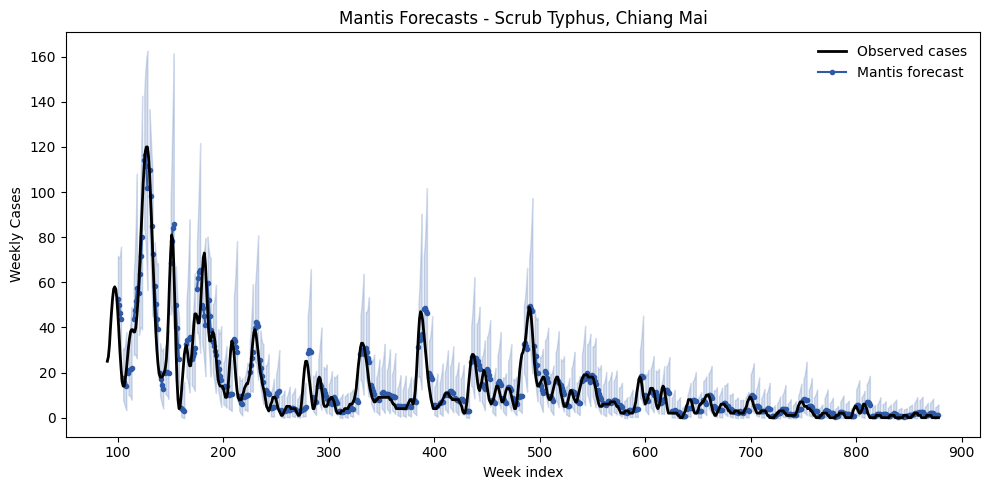

In [59]:
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = weekly_df.copy()

# Select province
province = "Chiang Mai"
df = df[df["Location"] == province].sort_index()

# Target and covariate series
cases_ts = df["Cases"].values          # target
weather_ts = df["RH"].values         # covariate

# Initialize model
model = Mantis(
    forecast_horizon=4,
    use_covariate=True
)

# Forecast weeks
forecast_weeks = list(range(100, len(cases_ts)-4, 5))

# Metrics storage
model_errors = []
baseline_errors = []
coverage_hits = 0
total_points = 0

forecasts = []
start_weeks = []

for week in forecast_weeks:
    if week + 4 > len(cases_ts):
        continue

    # 1. Prepare Inputs
    input_target = cases_ts[:week]
    input_cov = weather_ts[:week]
    true_future = cases_ts[week:week + 4]

    # 2. Naive Baseline Forecast (Last observed value repeated 4 weeks)
    naive_val = cases_ts[week - 1]
    baseline_pred = np.repeat(naive_val, 4)
    
    # 3. Model Prediction
    pred = model.predict(
        time_series=input_target,
        covariate=input_cov,
        target_type=2,
        covariate_type=1
    )

    # 4. Extract Prediction Components
    median = pred[:, 4]
    lower = pred[:, 0]
    upper = pred[:, 8]

    # 5. Compute Metrics for this window
    model_errors.extend(np.abs(true_future - median))
    baseline_errors.extend(np.abs(true_future - baseline_pred))
    
    # Coverage: check if truth falls within [lower, upper]
    hits = np.sum((true_future >= lower) & (true_future <= upper))
    coverage_hits += hits
    total_points += len(true_future)

    # Store for plotting
    forecasts.append(pred)
    start_weeks.append(week)

# --- Aggregate Metrics ---
avg_model_mae = np.mean(model_errors)
avg_baseline_mae = np.mean(baseline_errors)
rel_mae = avg_model_mae / avg_baseline_mae
coverage_pct = (coverage_hits / total_points) * 100

print(f"--- Performance Metrics: {province} ---")
print(f"Model MAE:         {avg_model_mae:.3f}")
print(f"Baseline MAE:      {avg_baseline_mae:.3f}")
print(f"Relative MAE:      {rel_mae:.3f} (Model / Baseline)")
print(f"Interval Coverage: {coverage_pct:.1f}%")

# --- Plotting ---
history_weeks = 10
first_week = int(start_weeks[0])
start_plot = max(0, first_week - history_weeks)
end_plot = int(start_weeks[-1]) + 4

weeks = np.arange(start_plot, end_plot)
truth_slice = cases_ts[start_plot:end_plot]

fig, ax = plt.subplots(figsize=(10, 5))

# Ground truth
ax.plot(weeks, truth_slice, color="black", linewidth=2, label="Observed cases", zorder=3)

labeled = False
for start, forecast in zip(start_weeks, forecasts):
    pred_weeks = np.arange(start, start + 4)
    
    # Extract bounds for plot
    med = forecast[:, 4]
    low = forecast[:, 0]
    high = forecast[:, 8]

    ax.fill_between(pred_weeks, low, high, color="#2f5aa8", alpha=0.2)
    ax.plot(pred_weeks, med, color="#2f5aa8", linewidth=1.5, marker="o", 
            markersize=3, label="Mantis forecast" if not labeled else None)
    labeled = True

ax.set_title(f"Mantis Forecasts - Scrub Typhus, {province}")
ax.set_xlabel("Week index")
ax.set_ylabel("Weekly Cases")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

# 4-week No Covariate Mantis
 Cases = Deaths
 
 Meteorological Covariate = Hospitalizations

In [76]:
import numpy as np
import pandas as pd

# Compare performance across weather covariates (same setup as above)

# Load dataset
run_df = weekly_df.copy()

# Select province
province = "Chiang Mai"
run_df = run_df[run_df["Location"] == province].sort_index()

# Target series
cases_ts = run_df["Cases"].values

# Covariates to test
covariates = [
    "Tavg", "Tmin", "Tmax", "RH", "specific.hum",
    "srf.pressure", "shortwave.rad", "precip",
    "runoff", "cld.frac", "pct_tree", "pct_hveg",
    "pct_bare", "lai_climo"
]

# Forecast weeks (same stride/horizon style as your cell)
forecast_weeks = list(range(50, len(cases_ts) - 4, 5))

# Initialize covariate-enabled model once
model = Mantis(
    forecast_horizon=4,
    use_covariate=True
)

results = []

for cov_name in covariates:
    # Skip missing/empty covariates safely
    if cov_name not in run_df.columns:
        continue

    weather_ts = run_df[cov_name].values

    model_errors = []
    baseline_errors = []
    coverage_hits = 0
    total_points = 0

    valid_windows = 0

    for week in forecast_weeks:
        if week + 4 > len(cases_ts):
            continue

        # Inputs
        input_target = cases_ts[:week]
        input_cov = weather_ts[:week]
        true_future = cases_ts[week:week + 4]

        # Naive baseline forecast
        naive_val = cases_ts[week - 1]
        baseline_pred = np.repeat(naive_val, 4)

        # Model prediction
        pred = model.predict(
            time_series=input_target,
            covariate=input_cov,
            target_type=2,
            covariate_type=1
        )

        median = pred[:, 4]
        lower = pred[:, 0]
        upper = pred[:, 8]

        model_errors.extend(np.abs(true_future - median))
        baseline_errors.extend(np.abs(true_future - baseline_pred))

        coverage_hits += np.sum((true_future >= lower) & (true_future <= upper))
        total_points += len(true_future)
        valid_windows += 1

    if len(model_errors) == 0 or len(baseline_errors) == 0:
        continue

    avg_model_mae = float(np.mean(model_errors))
    avg_baseline_mae = float(np.mean(baseline_errors))
    rel_mae = float(avg_model_mae / avg_baseline_mae) if avg_baseline_mae != 0 else np.nan
    coverage_pct = float((coverage_hits / total_points) * 100) if total_points > 0 else np.nan

    results.append(
        {
            "covariate": cov_name,
            "windows": valid_windows,
            "model_mae": avg_model_mae,
            "baseline_mae": avg_baseline_mae,
            "relative_mae": rel_mae,
            "coverage_pct": coverage_pct,
        }
    )

results_df = pd.DataFrame(results).sort_values("relative_mae")

print(f"--- Covariate Sensitivity: {province} ---")
print("(Lower relative_mae is better; <1 means model beats naive baseline)")
print(results_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))


--- Covariate Sensitivity: Chiang Mai ---
(Lower relative_mae is better; <1 means model beats naive baseline)
    covariate  windows  model_mae  baseline_mae  relative_mae  coverage_pct
 specific.hum      166     11.805        11.536         1.023        95.030
 srf.pressure      166     12.430        11.536         1.077        94.428
shortwave.rad      166     12.641        11.536         1.096        91.717
           RH      166     12.876        11.536         1.116        94.428
         Tmax      166     13.262        11.536         1.150        91.416
         Tavg      166     13.271        11.536         1.150        91.416
         Tmin      166     13.287        11.536         1.152        91.265
    lai_climo      166     13.287        11.536         1.152        91.265
     cld.frac      166     14.774        11.536         1.281        90.361
       precip      166        NaN        11.536           NaN         0.000
       runoff      166        NaN        11.536       

In [92]:
import numpy as np
import pandas as pd

# Province-level evaluation using the same setup as the single-province cell
# (covariate = RH, target_type=2, covariate_type=1, horizon=4, stride=20)

all_df = weekly_df.copy().sort_index()
provinces = sorted(all_df["Location"].dropna().unique())

model = Mantis(
    forecast_horizon=4,
    use_covariate=True
)

results = []

for province in provinces:
    df = all_df[all_df["Location"] == province].sort_index()

    # Need enough history for the first forecast start at week 50 + horizon 4
    if len(df) < 54:
        continue

    cases_ts = df["Cases"].values
    weather_ts = df["RH"].values  # same covariate as the reference cell

    forecast_weeks = list(range(50, len(cases_ts) - 4, 20))

    model_errors = []
    baseline_errors = []
    coverage_hits = 0
    total_points = 0
    valid_windows = 0

    for week in forecast_weeks:
        if week + 4 > len(cases_ts):
            continue

        input_target = cases_ts[:week]
        input_cov = weather_ts[:week]
        true_future = cases_ts[week:week + 4]

        naive_val = cases_ts[week - 1]
        baseline_pred = np.repeat(naive_val, 4)

        pred = model.predict(
            time_series=input_target,
            covariate=input_cov,
            target_type=2,
            covariate_type=0
        )

        median = pred[:, 4]
        lower = pred[:, 0]
        upper = pred[:, 8]

        model_errors.extend(np.abs(true_future - median))
        baseline_errors.extend(np.abs(true_future - baseline_pred))

        coverage_hits += np.sum((true_future >= lower) & (true_future <= upper))
        total_points += len(true_future)
        valid_windows += 1

    if len(model_errors) == 0 or len(baseline_errors) == 0:
        continue

    avg_model_mae = float(np.mean(model_errors))
    avg_baseline_mae = float(np.mean(baseline_errors))
    rel_mae = float(avg_model_mae / avg_baseline_mae) if avg_baseline_mae != 0 else np.nan
    coverage_pct = float((coverage_hits / total_points) * 100) if total_points > 0 else np.nan

    results.append(
        {
            "province": province,
            "windows": valid_windows,
            "forecast_points": total_points,
            "model_mae": avg_model_mae,
            "baseline_mae": avg_baseline_mae,
            "relative_mae": rel_mae,
            "coverage_pct": coverage_pct,
        }
    )

results_df = pd.DataFrame(results).sort_values("relative_mae")

print("--- Province-level Performance Metrics (covariate = RH) ---")
print("(Lower relative_mae is better; <1 means model beats naive baseline)")
print(results_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))


--- Province-level Performance Metrics (covariate = RH) ---
(Lower relative_mae is better; <1 means model beats naive baseline)
    province  windows  forecast_points  model_mae  baseline_mae  relative_mae  coverage_pct
    Songkhla       42              168      8.627        17.482         0.493        94.048
     Bangkok       42              168      3.186         4.798         0.664        99.405
Kanchanaburi       42              168     24.235        27.917         0.868        91.071
   Chon Buri       42              168      2.136         2.202         0.970        97.619
   Khon Kaen       42              168      0.837         0.845         0.990        97.619
  Chiang Mai       42              168      6.241         4.839         1.290        97.619


In [ ]:
# Multimodel probabilistic rolling evaluation (Mantis, ETS, SARIMAX, LSTM)
# - Retrains each model at each forecast origin
# - Uses target + covariate (RH) for each method
# - Reports relative MAE vs naive, interval coverage, and DM test p-values

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from scipy import stats
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from statsmodels.tsa.api import ETSModel
from statsmodels.tsa.statespace.sarimax import SARIMAX


# ----------------------------
# Configuration
# ----------------------------
PROVINCES = sorted(weekly_df["Location"].dropna().unique())
TARGET_COL = "Cases"
COVARIATE_COL = "RH"

FORECAST_HORIZON = 4
STRIDE = 20                # rolling
START_WEEK = 100            # first forecast origin
LOOKBACK = 16              # for LSTM supervised windows

QUANTILES = np.array([0.05, 0.1, 0.25, 0.4, 0.5, 0.6, 0.75, 0.9, 0.95], dtype=float)
MEDIAN_IDX = int(np.where(QUANTILES == 0.5)[0][0])

# LSTM hyperparameters (kept moderate for runtime)
LSTM_HIDDEN_DIM = 64
LSTM_NUM_LAYERS = 2
LSTM_DROPOUT = 0.2
LSTM_EPOCHS = 10
LSTM_BATCH_SIZE = 32
LSTM_LR = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ----------------------------
# Helpers
# ----------------------------

def make_gaussian_quantiles(mean, stderr, quantiles):
    """Build horizon x quantile array from Gaussian approx."""
    q = np.zeros((len(mean), len(quantiles)), dtype=float)
    for h in range(len(mean)):
        for j, qq in enumerate(quantiles):
            q[h, j] = mean[h] + stats.norm.ppf(qq) * stderr[h]
    return np.maximum(q, 0.0)


def ensure_monotonic_quantiles(q_preds):
    """Sort quantiles per horizon step to avoid crossings."""
    out = q_preds.copy()
    for h in range(out.shape[0]):
        out[h, :] = np.sort(out[h, :])
    return out


def compute_window_metrics(true_future, q_preds, baseline_pred):
    """Return (model_abs_errors, baseline_abs_errors, cov90_hits, cov50_hits)."""
    median = q_preds[:, MEDIAN_IDX]

    model_abs = np.abs(true_future - median)
    base_abs = np.abs(true_future - baseline_pred)

    low90 = q_preds[:, 0]
    up90 = q_preds[:, 8]
    cov90_hits = np.sum((true_future >= low90) & (true_future <= up90))

    low50 = q_preds[:, 2]
    up50 = q_preds[:, 6]
    cov50_hits = np.sum((true_future >= low50) & (true_future <= up50))

    return model_abs, base_abs, cov90_hits, cov50_hits


def dm_test(loss1, loss2, h=1):
    """
    Diebold-Mariano test for predictive accuracy.
    loss1, loss2: Arrays of forecast losses (e.g., absolute errors).
    h: Forecast horizon (for autocorrelation robust variance).
    Returns the two-sided p-value.
    """
    d = np.array(loss1) - np.array(loss2)
    T = len(d)
    if T == 0:
        return np.nan

    mean_d = np.mean(d)

    # Autocovariance function
    def autocov(x, lag):
        if lag == 0:
            return np.var(x, ddof=0)
        return np.mean((x[:-lag] - mean_d) * (x[lag:] - mean_d))

    gamma_0 = autocov(d, 0)
    var_d = gamma_0

    # Add covariance terms for h-1 lags
    for k in range(1, h):
        var_d += 2 * autocov(d, k)

    if var_d <= 1e-8:
        return np.nan

    dm_stat = mean_d / np.sqrt(var_d / T)
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    return p_value


class QuantileLoss(nn.Module):
    def __init__(self, quantiles):
        super().__init__()
        self.quantiles = torch.tensor(quantiles, dtype=torch.float32)

    def forward(self, preds, target):
        # preds: [B, H, Q], target: [B, H]
        target_exp = target.unsqueeze(-1).expand_as(preds)
        q = self.quantiles.to(preds.device).view(1, 1, -1)
        errors = target_exp - preds
        loss = torch.max((q - 1) * errors, q * errors)
        return loss.mean()


class LSTMQuantileForecaster(nn.Module):
    """
    Uses historical (target+covariate) sequence and known future covariates to forecast quantiles.
    """
    def __init__(self, hidden_dim, horizon, n_quantiles, num_layers=2, dropout=0.2):
        super().__init__()
        self.horizon = horizon
        self.n_quantiles = n_quantiles

        self.lstm = nn.LSTM(
            input_size=2,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.bn = nn.BatchNorm1d(hidden_dim)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim + horizon, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, horizon * n_quantiles),
        )

    def forward(self, x_hist, x_future_cov, use_bn=True):
        # x_hist: [B, L, 2], x_future_cov: [B, H]
        out, _ = self.lstm(x_hist)
        h = out[:, -1, :]
        if use_bn and h.shape[0] > 1:
            h = self.bn(h)
        z = torch.cat([h, x_future_cov], dim=1)
        y = self.head(z)
        y = y.view(-1, self.horizon, self.n_quantiles)
        return y


# ----------------------------
# Per-model forecasters
# ----------------------------

def forecast_mantis(y_hist, x_hist):
    pred = mantis_model.predict(
        time_series=y_hist,
        covariate=x_hist,
        target_type=2,
        covariate_type=1,
    )
    return ensure_monotonic_quantiles(pred)


def forecast_ets_with_covariate(y_hist, x_hist, x_future_proxy):
    X = np.column_stack([np.ones(len(x_hist)), x_hist])
    beta, *_ = np.linalg.lstsq(X, y_hist, rcond=None)
    a, b = float(beta[0]), float(beta[1])
    y_det_hist = a + b * x_hist
    resid_hist = np.asarray(y_hist - y_det_hist, dtype=float)

    if len(resid_hist) < 8:
        raise ValueError("Not enough history for ETS")

    # Wrap in a Series so statsmodels doesn't choke on missing .index
    resid_series = pd.Series(resid_hist)

    use_seasonal = len(resid_hist) >= 2 * 52 and np.nanstd(resid_hist) > 1e-8
    ets_specs = []
    if use_seasonal:
        ets_specs.append(dict(error="add", trend="add", seasonal="add", seasonal_periods=52))
    ets_specs.extend([
        dict(error="add", trend="add", seasonal=None),
        dict(error="add", trend=None, seasonal=None),
    ])

    last_err = None
    for spec in ets_specs:
        try:
            model = ETSModel(resid_series, **spec)  # <-- Series, not array
            fit = model.fit(disp=False)
            pred_obj = fit.get_prediction(
                start=len(resid_hist),
                end=len(resid_hist) + FORECAST_HORIZON - 1,
            )
            resid_mean = np.asarray(pred_obj.predicted_mean, dtype=float)

            in_sample_resid = np.asarray(fit.resid, dtype=float)
            in_sample_resid = in_sample_resid[np.isfinite(in_sample_resid)]
            resid_std = max(np.nanstd(in_sample_resid, ddof=1), 1e-3)
            horizon_se = resid_std * np.sqrt(np.arange(1, FORECAST_HORIZON + 1))

            y_det_future = a + b * x_future_proxy
            total_mean = y_det_future + resid_mean
            q_preds = make_gaussian_quantiles(total_mean, horizon_se + 1e-6, QUANTILES)
            return ensure_monotonic_quantiles(q_preds)

        except Exception as err:
            last_err = err

    raise RuntimeError(f"ETS failed for all specs: {last_err}")


def forecast_sarimax_with_covariate(y_hist, x_hist, x_future_proxy):
    exog_hist = np.asarray(x_hist, dtype=float).reshape(-1, 1)
    exog_future = np.asarray(x_future_proxy, dtype=float).reshape(-1, 1)

    # Faster/stabler than (2,2,2)x(2,1,1,52) at each rolling origin.
    seasonal_order = (1, 0, 0, 52) if len(y_hist) >= 3 * 52 else (0, 0, 0, 0)
    model = SARIMAX(
        y_hist,
        exog=exog_hist,
        order=(1, 1, 1),
        seasonal_order=seasonal_order,
        trend="n",
        simple_differencing=True,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fit = model.fit(disp=False, method="lbfgs", maxiter=40)

    fc = fit.get_forecast(steps=FORECAST_HORIZON, exog=exog_future)
    mean = np.asarray(fc.predicted_mean, dtype=float)

    if hasattr(fc, "se_mean") and fc.se_mean is not None:
        se = np.asarray(fc.se_mean, dtype=float)
    else:
        pred_var = np.asarray(fc.var_pred_mean, dtype=float)
        se = np.sqrt(np.maximum(pred_var, 1e-8))

    q_preds = make_gaussian_quantiles(mean, se + 1e-6, QUANTILES)
    return ensure_monotonic_quantiles(q_preds)


def forecast_lstm_quantile(y_hist, x_hist, x_future_proxy):
    """Train-from-scratch LSTM quantile model at each origin."""
    n = len(y_hist)
    if n < LOOKBACK + FORECAST_HORIZON + 1:
        raise ValueError("Not enough history for LSTM training window")

    # Build supervised training set from history
    X_hist, X_future_cov, Y = [], [], []
    for i in range(LOOKBACK, n - FORECAST_HORIZON + 1):
        hist_target = y_hist[i - LOOKBACK:i]
        hist_cov = x_hist[i - LOOKBACK:i]
        fut_cov = x_hist[i:i + FORECAST_HORIZON]
        fut_target = y_hist[i:i + FORECAST_HORIZON]

        if len(fut_target) == FORECAST_HORIZON:
            X_hist.append(np.column_stack([hist_target, hist_cov]))
            X_future_cov.append(fut_cov)
            Y.append(fut_target)

    X_hist = np.asarray(X_hist, dtype=float)           # [N, L, 2]
    X_future_cov = np.asarray(X_future_cov, dtype=float)  # [N, H]
    Y = np.asarray(Y, dtype=float)                     # [N, H]

    if len(X_hist) < 2:
        raise ValueError("Too few samples for LSTM")

    # Scale
    scaler_hist = StandardScaler()
    scaler_future_cov = StandardScaler()
    scaler_y = StandardScaler()

    X_hist_s = scaler_hist.fit_transform(X_hist.reshape(-1, 2)).reshape(X_hist.shape)
    X_future_cov_s = scaler_future_cov.fit_transform(X_future_cov)
    Y_s = scaler_y.fit_transform(Y.reshape(-1, 1)).reshape(Y.shape)

    # Tensors
    X_hist_t = torch.tensor(X_hist_s, dtype=torch.float32, device=DEVICE)
    X_future_cov_t = torch.tensor(X_future_cov_s, dtype=torch.float32, device=DEVICE)
    Y_t = torch.tensor(Y_s, dtype=torch.float32, device=DEVICE)

    ds = TensorDataset(X_hist_t, X_future_cov_t, Y_t)
    bs = min(LSTM_BATCH_SIZE, len(ds))
    dl = DataLoader(ds, batch_size=bs, shuffle=True, drop_last=False)

    model = LSTMQuantileForecaster(
        hidden_dim=LSTM_HIDDEN_DIM,
        horizon=FORECAST_HORIZON,
        n_quantiles=len(QUANTILES),
        num_layers=LSTM_NUM_LAYERS,
        dropout=LSTM_DROPOUT,
    ).to(DEVICE)

    opt = torch.optim.Adam(model.parameters(), lr=LSTM_LR)
    loss_fn = QuantileLoss(QUANTILES)

    model.train()
    for _ in range(LSTM_EPOCHS):
        for xb_hist, xb_fc, yb in dl:
            opt.zero_grad()
            pred = model(xb_hist, xb_fc, use_bn=True)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()

    # Inference at current origin
    hist_now = np.column_stack([y_hist[-LOOKBACK:], x_hist[-LOOKBACK:]])
    fut_cov_now = np.asarray(x_future_proxy, dtype=float).reshape(1, -1)

    hist_now_s = scaler_hist.transform(hist_now).reshape(1, LOOKBACK, 2)
    fut_cov_now_s = scaler_future_cov.transform(fut_cov_now)

    hist_now_t = torch.tensor(hist_now_s, dtype=torch.float32, device=DEVICE)
    fut_cov_now_t = torch.tensor(fut_cov_now_s, dtype=torch.float32, device=DEVICE)

    model.eval()
    with torch.no_grad():
        q_scaled = model(hist_now_t, fut_cov_now_t, use_bn=False).squeeze(0).cpu().numpy()  # [H, Q]

    # Inverse-transform each quantile path using target scaler
    q = np.zeros_like(q_scaled)
    for q_idx in range(q.shape[1]):
        q[:, q_idx] = scaler_y.inverse_transform(q_scaled[:, q_idx].reshape(-1, 1)).ravel()

    q = np.maximum(q, 0.0)
    return ensure_monotonic_quantiles(q)


# ----------------------------
# Run rolling evaluation
# ----------------------------

mantis_model = Mantis(forecast_horizon=FORECAST_HORIZON, use_covariate=True)

methods = ["mantis", "ets_x", "sarimax_x", "lstm_q"]
stats_store = {
    m: {
        "model_abs": [],
        "baseline_abs": [],
        "cov90_hits": 0,
        "cov50_hits": 0,
        "total_points": 0,
        "fallbacks": 0,
    }
    for m in methods
}

for province in PROVINCES:
    dfp = weekly_df[weekly_df["Location"] == province].sort_index()
    if len(dfp) < START_WEEK + FORECAST_HORIZON + 1:
        continue

    y = dfp[TARGET_COL].astype(float).values
    x = dfp[COVARIATE_COL].astype(float).values

    for t in tqdm(range(START_WEEK, len(y) - FORECAST_HORIZON + 1, STRIDE),
                  desc=f"{province}", leave=False):
        y_hist = y[:t]
        x_hist = x[:t]
        y_true = y[t:t + FORECAST_HORIZON]
        # Do not use true future covariates; use last observed value as proxy.
        x_future_proxy = np.repeat(x_hist[-1], FORECAST_HORIZON)

        if len(y_true) < FORECAST_HORIZON:
            continue

        baseline_pred = np.repeat(y_hist[-1], FORECAST_HORIZON)

        # Mantis
        try:
            q_mantis = forecast_mantis(y_hist, x_hist)
        except Exception:
            stats_store["mantis"]["fallbacks"] += 1
            q_mantis = np.tile(baseline_pred.reshape(-1, 1), (1, len(QUANTILES)))

        m_abs, b_abs, c90, c50 = compute_window_metrics(y_true, q_mantis, baseline_pred)
        stats_store["mantis"]["model_abs"].extend(m_abs)
        stats_store["mantis"]["baseline_abs"].extend(b_abs)
        stats_store["mantis"]["cov90_hits"] += int(c90)
        stats_store["mantis"]["cov50_hits"] += int(c50)
        stats_store["mantis"]["total_points"] += FORECAST_HORIZON

        # ETS+X
        try:
            q_ets = forecast_ets_with_covariate(y_hist, x_hist, x_future_proxy)
        except Exception as e:
            print(f"ETS failed: {type(e).__name__}: {e}")
            stats_store["ets_x"]["fallbacks"] += 1
            q_ets = np.tile(baseline_pred.reshape(-1, 1), (1, len(QUANTILES)))

        m_abs, b_abs, c90, c50 = compute_window_metrics(y_true, q_ets, baseline_pred)
        stats_store["ets_x"]["model_abs"].extend(m_abs)
        stats_store["ets_x"]["baseline_abs"].extend(b_abs)
        stats_store["ets_x"]["cov90_hits"] += int(c90)
        stats_store["ets_x"]["cov50_hits"] += int(c50)
        stats_store["ets_x"]["total_points"] += FORECAST_HORIZON

        # SARIMAX+X
        try:
            q_sarima = forecast_sarimax_with_covariate(y_hist, x_hist, x_future_proxy)
        except Exception:
            stats_store["sarimax_x"]["fallbacks"] += 1
            q_sarima = np.tile(baseline_pred.reshape(-1, 1), (1, len(QUANTILES)))

        m_abs, b_abs, c90, c50 = compute_window_metrics(y_true, q_sarima, baseline_pred)
        stats_store["sarimax_x"]["model_abs"].extend(m_abs)
        stats_store["sarimax_x"]["baseline_abs"].extend(b_abs)
        stats_store["sarimax_x"]["cov90_hits"] += int(c90)
        stats_store["sarimax_x"]["cov50_hits"] += int(c50)
        stats_store["sarimax_x"]["total_points"] += FORECAST_HORIZON

        # LSTM quantile
        try:
            q_lstm = forecast_lstm_quantile(y_hist, x_hist, x_future_proxy)
        except Exception:
            stats_store["lstm_q"]["fallbacks"] += 1
            q_lstm = np.tile(baseline_pred.reshape(-1, 1), (1, len(QUANTILES)))

        m_abs, b_abs, c90, c50 = compute_window_metrics(y_true, q_lstm, baseline_pred)
        stats_store["lstm_q"]["model_abs"].extend(m_abs)
        stats_store["lstm_q"]["baseline_abs"].extend(b_abs)
        stats_store["lstm_q"]["cov90_hits"] += int(c90)
        stats_store["lstm_q"]["cov50_hits"] += int(c50)
        stats_store["lstm_q"]["total_points"] += FORECAST_HORIZON


# ----------------------------
# Summarize
# ----------------------------
summary_rows = []
mantis_errors = stats_store["mantis"]["model_abs"]

for method in methods:
    s = stats_store[method]

    model_mae = float(np.mean(s["model_abs"])) if len(s["model_abs"]) else np.nan
    baseline_mae = float(np.mean(s["baseline_abs"])) if len(s["baseline_abs"]) else np.nan
    relative_mae = model_mae / baseline_mae if (np.isfinite(baseline_mae) and baseline_mae != 0) else np.nan

    cov90 = (s["cov90_hits"] / s["total_points"]) if s["total_points"] > 0 else np.nan
    cov50 = (s["cov50_hits"] / s["total_points"]) if s["total_points"] > 0 else np.nan

    # Calculate DM test p-value comparing Mantis to the current method
    if method == "mantis":
        dm_pval = np.nan
    else:
        dm_pval = dm_test(mantis_errors, s["model_abs"], h=FORECAST_HORIZON)

    summary_rows.append(
        {
            "method": method,
            "model_mae": model_mae,
            "relative_mae": relative_mae,
            "coverage_50": cov50,
            "coverage_90": cov90,
            "dm_p_value": dm_pval,
            "fallback_count": s["fallbacks"],
            "forecast_points": s["total_points"],
        }
    )

summary_df = pd.DataFrame(summary_rows).sort_values("relative_maeI")

print("\n=== Multimodel Probabilistic Rolling Evaluation ===")
print(f"Target: {TARGET_COL}, Covariate: {COVARIATE_COL}, Horizon: {FORECAST_HORIZON}, Stride: {STRIDE}")
print("Relative MAE = model MAE / naive baseline MAE (lower is better; <1 beats baseline)")
print("dm_p_value = Diebold-Mariano test p-value comparing Mantis vs. method (H0: equal predictive accuracy)")
print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


=== Multimodel Probabilistic Rolling Evaluation ===
Target: Cases, Covariate: RH, Horizon: 4, Stride: 20
Relative MAE = model MAE / naive baseline MAE (lower is better; <1 beats baseline)
dm_p_value = Diebold-Mariano test p-value comparing Mantis vs. method (H0: equal predictive accuracy)
   method  model_mae  relative_mae  coverage_50  coverage_90  dm_p_value  fallback_count  forecast_points
   mantis     9.2703        1.0140       0.6015       0.9509         NaN               0              936
    ets_x     9.7727        1.0690       0.4626       0.7254      0.7471               0              936
sarimax_x    28.7628        3.1462       0.2746       0.4444      0.0000               0              936
   lstm_q    36.9583        4.0427       0.0513       0.1036      0.0000               0              936


/Users/cdud/Desktop/Research/marisa_research/mantis/mantis_eval/Mantis/mantis/inference.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_pa

Covariate run (target_type=2, covariate_type=1)
Mean relative MAE over windows: 1.6765


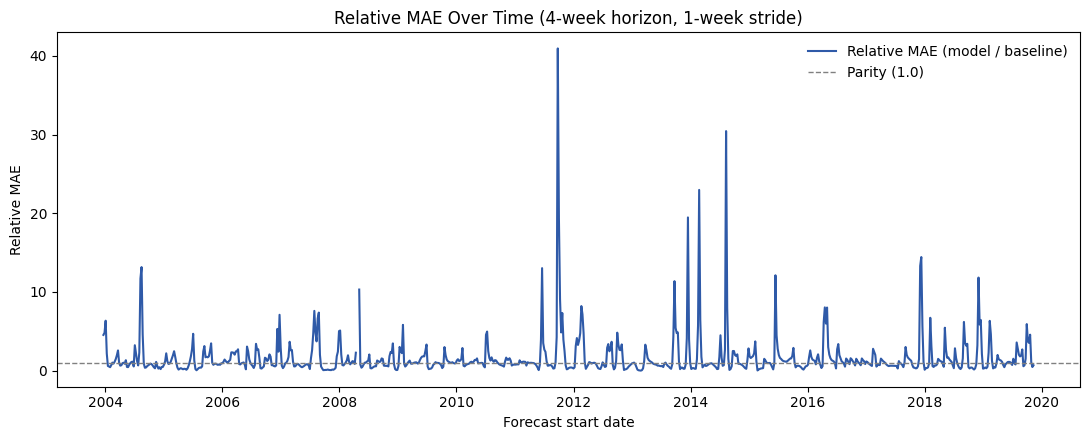

In [20]:
# Relative MAE over time for Covariate run (target_type=2, covariate_type=1)

province = "Chiang Mai"
run_df = weekly_df[weekly_df["Location"] == province].sort_index()

cases_ts = run_df["Cases"].values
weather_ts = run_df["specific.hum"].values

model = Mantis(
    forecast_horizon=4,
    use_covariate=True,
)

forecast_weeks = range(50, len(cases_ts) - 4 + 1, 1)

start_dates = []
relative_mae_over_time = []
model_mae_over_time = []
baseline_mae_over_time = []

for week in forecast_weeks:
    input_target = cases_ts[:week]
    input_cov = weather_ts[:week]
    true_future = cases_ts[week:week + 4]

    pred = model.predict(
        time_series=input_target,
        covariate=input_cov,
        target_type=2,
        covariate_type=1,
    )

    median = pred[:, 4]
    naive_pred = np.full(4, input_target[-1])

    model_mae_window = float(np.mean(np.abs(median - true_future)))
    baseline_mae_window = float(np.mean(np.abs(naive_pred - true_future)))

    if baseline_mae_window == 0:
        rel = np.nan
    else:
        rel = model_mae_window / baseline_mae_window

    start_dates.append(run_df.index[week])
    relative_mae_over_time.append(rel)
    model_mae_over_time.append(model_mae_window)
    baseline_mae_over_time.append(baseline_mae_window)


metrics_df = pd.DataFrame(
    {
        "model_mae": model_mae_over_time,
        "baseline_mae": baseline_mae_over_time,
        "relative_mae": relative_mae_over_time,
    },
    index=pd.to_datetime(start_dates),
)

print("Covariate run (target_type=2, covariate_type=1)")
print(f"Mean relative MAE over windows: {np.nanmean(metrics_df['relative_mae']):.4f}")

plt.figure(figsize=(11, 4.5))
plt.plot(metrics_df.index, metrics_df["relative_mae"], color="#2f5aa8", linewidth=1.5, label="Relative MAE (model / baseline)")
plt.axhline(1.0, color="gray", linestyle="--", linewidth=1.0, label="Parity (1.0)")
plt.title("Relative MAE Over Time (4-week horizon, 1-week stride)")
plt.xlabel("Forecast start date")
plt.ylabel("Relative MAE")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [13]:
# Relative baseline evaluation (1-week stride, 4-week horizon)


def evaluate_mantis_run(df, province, use_covariate, target_type, covariate_type=None):
    run_df = df[df["Location"] == province].sort_index()
    cases_ts = run_df["Cases"].values
    weather_ts = run_df["Tmax"].values

    model = Mantis(
        forecast_horizon=4,
        use_covariate=use_covariate,
    )

    # 4-week horizon with 1-week stride
    forecast_weeks = range(50, len(cases_ts) - 4 + 1, 1)

    model_abs_errors = []
    naive_abs_errors = []
    coverage_hits = 0
    coverage_total = 0

    for week in forecast_weeks:
        input_target = cases_ts[:week]
        true_future = cases_ts[week:week + 4]

        # Naive baseline: hold current value constant over horizon
        naive_pred = np.full(4, input_target[-1])

        if use_covariate:
            input_cov = weather_ts[:week]
            pred = model.predict(
                time_series=input_target,
                covariate=input_cov,
                target_type=target_type,
                covariate_type=covariate_type,
            )
        else:
            pred = model.predict(
                time_series=input_target,
                target_type=target_type,
            )

        # Mantis outputs quantiles; use q0.5 for point forecast
        median = pred[:, 4]
        lower = pred[:, 0]
        upper = pred[:, 8]

        model_abs_errors.extend(np.abs(median - true_future))
        naive_abs_errors.extend(np.abs(naive_pred - true_future))

        coverage_hits += np.sum((true_future >= lower) & (true_future <= upper))
        coverage_total += len(true_future)

    model_mae = float(np.mean(model_abs_errors))
    baseline_mae = float(np.mean(naive_abs_errors))
    relative_mae = model_mae / baseline_mae if baseline_mae != 0 else np.nan
    coverage = coverage_hits / coverage_total if coverage_total > 0 else np.nan

    return {
        "model_mae": model_mae,
        "baseline_mae": baseline_mae,
        "relative_mae": relative_mae,
        "coverage": coverage,
        "n_windows": len(list(forecast_weeks)),
        "n_points": coverage_total,
    }


province = "Chiang Mai"

runs = [
    {
        "name": "Covariate run (target_type=1, covariate_type=0)",
        "use_covariate": True,
        "target_type": 1,
        "covariate_type": 0,
    },
    {
        "name": "Covariate run (target_type=2, covariate_type=1)",
        "use_covariate": True,
        "target_type": 2,
        "covariate_type": 1,
    },
    {
        "name": "No-covariate run (target_type=0)",
        "use_covariate": False,
        "target_type": 0,
        "covariate_type": None,
    },
]

print("Relative baseline evaluation (naive = last observed value carried forward)")
for run in runs:
    metrics = evaluate_mantis_run(
        weekly_df,
        province,
        use_covariate=run["use_covariate"],
        target_type=run["target_type"],
        covariate_type=run["covariate_type"],
    )

    print("\n" + run["name"])
    print(f"  Windows evaluated: {metrics['n_windows']}")
    print(f"  Forecast points:   {metrics['n_points']}")
    print(f"  Model MAE:         {metrics['model_mae']:.4f}")
    print(f"  Naive MAE:         {metrics['baseline_mae']:.4f}")
    print(f"  Relative MAE:      {metrics['relative_mae']:.4f}  (model / naive)")
    print(f"  90% coverage:      {metrics['coverage']:.2%}")


Relative baseline evaluation (naive = last observed value carried forward)

Covariate run (target_type=1, covariate_type=0)
  Windows evaluated: 830
  Forecast points:   3320
  Model MAE:         10.5113
  Naive MAE:         10.3843
  Relative MAE:      1.0122  (model / naive)
  90% coverage:      93.80%

Covariate run (target_type=2, covariate_type=1)
  Windows evaluated: 830
  Forecast points:   3320
  Model MAE:         10.4423
  Naive MAE:         10.3843
  Relative MAE:      1.0056  (model / naive)
  90% coverage:      90.48%

No-covariate run (target_type=0)
  Windows evaluated: 830
  Forecast points:   3320
  Model MAE:         12.3901
  Naive MAE:         10.3843
  Relative MAE:      1.1932  (model / naive)
  90% coverage:      99.73%


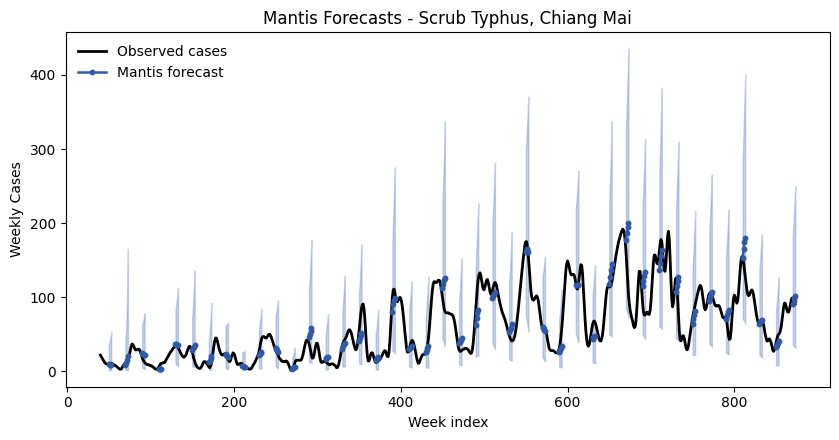

In [14]:
# Load dataset
df = weekly_df.copy()

# Select province
province = "Chiang Mai"
df = df[df["Location"] == province].sort_index()


# Target and covariate series
cases_ts = df["Cases"].values          # target
weather_ts = df["Tmax"].values         # covariate

# Initialize model
model = Mantis(
    forecast_horizon=4,
    use_covariate=False
)

# Forecast weeks
forecast_weeks = list(range(50, len(cases_ts)-4, 20))

forecasts = []
ground_truths = []
start_weeks = []

for week in forecast_weeks:

    if week + 4 > len(cases_ts):
        continue

    # Leading signal = cases
    input_target = cases_ts[:week]

    # Lagging signal = weather
    input_cov = weather_ts[:week]

    true_future = cases_ts[week:week + 4]

    pred = model.predict(
        time_series=input_target,
        target_type=0       # generic target
    )

    forecasts.append(pred)
    ground_truths.append(true_future)
    start_weeks.append(week)


# Plot window
history_weeks = 10

first_week = int(start_weeks[0])
start_plot = max(0, first_week - history_weeks)
end_plot = int(start_weeks[-1]) + 4

weeks = np.arange(start_plot, end_plot)
truth_slice = cases_ts[start_plot:end_plot]

# Plot
fig, ax = plt.subplots(figsize=(8.5, 4.5))

# Ground truth
ax.plot(
    weeks,
    truth_slice,
    color="black",
    linewidth=2,
    label="Observed cases"
)

labeled = False

for start, forecast in zip(start_weeks, forecasts):

    pred_weeks = np.arange(start, start + 4)

    median = forecast[:, 4]
    lower = forecast[:, 0]
    upper = forecast[:, 8]

    ax.fill_between(
        pred_weeks,
        lower,
        upper,
        color="#2f5aa8",
        alpha=0.25
    )

    ax.plot(
        pred_weeks,
        median,
        color="#2f5aa8",
        linewidth=1.8,
        marker="o",
        markersize=3.2,
        label="Mantis forecast" if not labeled else None
    )

    labeled = True

# Labels
ax.set_title("Mantis Forecasts - Scrub Typhus, Chiang Mai")
ax.set_xlabel("Week index")
ax.set_ylabel("Weekly Cases")

ax.legend(frameon=False)

plt.tight_layout()
plt.show()